# Clustering — New Approach (Group 68)

This notebook builds customer-level feature sets and runs clustering from multiple **perspectives**:
- **Behavior** (flight activity & engagement)
- **Value** (CLV-based)
- **Demographics** (Income + categorical profile)

Workflow: load → aggregate per customer → engineer features → scale → pick $k$ via metrics → fit final models → interpret clusters (PCA + radar charts).

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from typing import Iterable, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create directory for plots
output_dir = 'Plots'
os.makedirs(output_dir, exist_ok=True)

## Setup

Imports, plotting defaults, and a `Plots/` folder where figures get saved.

In [2]:
# Load the cleaned dataset from Delivery 1
df = pd.read_csv('Data/DM_AIAI_FinalCustomerSegments.csv')
print(f"Raw dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique customers: {df['Loyalty#'].nunique():,}")

Raw dataset loaded: 602,532 rows × 40 columns
Unique customers: 16,737


## Load data

Loads the cleaned dataset from Delivery 1. At this point the data is still *row-level* (multiple flights/records per customer).

In [3]:
df.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,avg_km_per_flight,avg_points_per_flight,redemption_ratio,points_balance,active_days,months_since_flight,companion_ratio,clv_per_flight,clv_to_salary_ratio,loyalty_tier_numeric,preliminary_segment
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,5,2020-05-01,13,4,25010.0,2501.0,0.0,0.0,1786.428571,178.642857,0.0,2501.0,2501,19,0.285714,274.224286,0.05473,1,Dormant
1,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,4,2020-04-01,0,0,5095.0,509.0,0.0,0.0,5095.000000,509.000000,0.0,509.0,2501,20,0.000000,3839.140000,0.05473,1,Dormant
2,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,2,2020-02-01,3,0,24271.0,2427.0,0.0,0.0,6067.750000,606.750000,0.0,2427.0,2501,22,0.000000,959.785000,0.05473,1,Dormant
3,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,3,2020-03-01,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2501,21,0.000000,3839.140000,0.05473,1,Dormant
4,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaN,3839.14,Standard,2020,1,2020-01-01,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2501,23,0.000000,3839.140000,0.05473,1,Dormant


## Aggregate to customer level

Clustering is performed at the **customer** level, so we aggregate rows by `Loyalty#`:
- Demographics/location: take the most common value (mode)
- Activity/value: sum totals across records
- Recency/activity window: take min/max depending on meaning
- Create derived ratios (e.g., average km per flight)

In [4]:
customer_agg = df.groupby('Loyalty#').agg({
    'Country': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Province or State': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'City': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Gender': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Education': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'Income': 'first',
    'Marital Status': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
    'LoyaltyStatus': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],

    'NumFlights': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',

    'Customer Lifetime Value': 'first',

    'months_since_flight': 'min',
    'active_days': 'max'
}).reset_index()

customer_agg['avg_km_per_flight'] = customer_agg['DistanceKM'] / customer_agg['NumFlights'].replace(0, 1)
customer_agg['avg_points_per_flight'] = customer_agg['PointsAccumulated'] / customer_agg['NumFlights'].replace(0, 1)
customer_agg['clv_per_flight'] = customer_agg['Customer Lifetime Value'] / customer_agg['NumFlights'].replace(0, 1)

customer_agg['redemption_rate'] = (
    customer_agg['PointsRedeemed'] / customer_agg['PointsAccumulated'].replace(0, 1)
) * 100

df = customer_agg.copy()

## Feature sets ("perspectives")

Instead of clustering on one large mixed feature space, we create **separate feature sets**:
- **Behavior**: how customers fly and engage (frequency, recency, activity)
- **Value**: how valuable they are (CLV-based)
- **Demographics**: who they are (Income + Education/Marital Status)

This makes the results easier to interpret and lets us compare segmentations across different business viewpoints.

In [5]:
behavior_features = [
    "NumFlights",
    "avg_km_per_flight",
    "avg_points_per_flight",
    "months_since_flight",
    "active_days",
    "redemption_rate",
]

value_features = [
    "Customer Lifetime Value",
    "clv_per_flight",
]

demo_features = [
    "Income",
    "Education",
    "Marital Status",
]

X_behavior_df = df[behavior_features].copy()
X_value_df = df[value_features].copy()

X_demo_df = df[demo_features].copy()
X_demo_encoded = pd.get_dummies(X_demo_df, columns=["Education", "Marital Status"], drop_first=True)


In [6]:
X_behavior_df.head()

,NumFlights,avg_km_per_flight,avg_points_per_flight,months_since_flight,active_days,redemption_rate
0,231,2295.367965,229.499134,0,2326,38.787271
1,248,1367.397581,136.709516,0,3574,55.334539
2,217,1990.925346,199.044147,0,2336,11.335280
3,112,3255.372321,325.480089,0,2694,35.410878
4,187,2297.489305,229.696524,0,3268,25.356405


In [7]:
X_value_df.head()

,Customer Lifetime Value,clv_per_flight
0,7919.20,34.282251
1,2887.74,11.644113
2,2838.07,13.078664
3,4170.57,37.237232
4,6622.05,35.412032


In [8]:
X_demo_df.head()

,Income,Education,Marital Status
0,82877.0,Bachelor,Married
1,0.0,College,Single
2,0.0,College,Divorced
3,42837.0,Bachelor,Married
4,80979.0,Bachelor,Divorced


## Encoding + scaling (why it matters)

Clustering is distance-based, so we need comparable feature scales.
- **Numeric** features are standardized with `StandardScaler` so no single unit dominates (e.g., CLV vs counts).
- **Categorical** demographics are one-hot encoded (Education / Marital Status) so clusters can reflect category composition.

Note: Ward linkage (Agglomerative) and KMeans both assume Euclidean geometry, which is why standardization is a good default here.

In [9]:
scaler = StandardScaler()

X_behavior = StandardScaler().fit_transform(X_behavior_df)
X_value = StandardScaler().fit_transform(X_value_df)
X_demo = StandardScaler().fit_transform(X_demo_encoded)

customer_ids = df["Loyalty#"].values

print("Behavior:", X_behavior.shape, behavior_features)
print("Value:", X_value.shape, value_features)
print("Demo:", X_demo.shape, "encoded_cols=", X_demo_encoded.shape[1])

Behavior: (16737, 6) ['NumFlights', 'avg_km_per_flight', 'avg_points_per_flight', 'months_since_flight', 'active_days', 'redemption_rate']
Value: (16737, 2) ['Customer Lifetime Value', 'clv_per_flight']
Demo: (16737, 7) encoded_cols= 7


## Methods & model selection (why these choices)

We compare two complementary clustering approaches:
- **KMeans**: fast, works well when clusters are roughly spherical in feature space; provides clear centroids.
- **Agglomerative (Ward)**: hierarchical method that merges clusters to minimize within-cluster variance; often yields more stable partitions.

To select the number of clusters $k$, we evaluate standard internal validation metrics across a range of $k$:
- **Silhouette** (higher is better)
- **Davies–Bouldin** (lower is better)

We primarily choose $k$ by **silhouette** for a single, consistent rule.

In [10]:
def _clustering_metrics(X: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    return float(sil), float(db)

def evaluate_k_kmeans(X: np.ndarray,k_values: Iterable[int] = range(2, 11),random_state: int = 42,n_init: int = 20,) -> pd.DataFrame:
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=int(k), random_state=random_state, n_init=n_init)
        labels = model.fit_predict(X)
        sil, db = _clustering_metrics(X, labels)
        rows.append({
            "algorithm": "kmeans",
            "k": int(k),
            "inertia": float(model.inertia_),
            "silhouette": sil,
            "davies_bouldin": db,
        })
    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

def evaluate_k_agglomerative(X: np.ndarray,k_values: Iterable[int] = range(2, 11),linkage: str = "ward",) -> pd.DataFrame:
    rows = []
    for k in k_values:
        # ward requires Euclidean distances and works well with standardized numeric features.
        model = AgglomerativeClustering(n_clusters=int(k), linkage=linkage)
        labels = model.fit_predict(X)
        sil, db = _clustering_metrics(X, labels)
        rows.append({
            "algorithm": f"agglomerative_{linkage}",
            "k": int(k),
            "inertia": np.nan,
            "silhouette": sil,
            "davies_bouldin": db,
        })
    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

def pick_best_k(results: pd.DataFrame, metric: str = "silhouette") -> int:
    if metric == "silhouette":
        return int(results.loc[results[metric].idxmax(), "k"])
    if metric in {"davies_bouldin", "inertia"}:
        return int(results.loc[results[metric].idxmin(), "k"])
    return int(results.loc[results[metric].idxmax(), "k"])

## Optimal k search (separated cells)

Each of the following cells computes the *optimal k* (by silhouette) for one **feature set × algorithm** pair.

In [11]:
k_values = range(2, 11)

feature_sets = {
    "behavior": X_behavior,
    "value": X_value,
    "demo": X_demo,
}

all_results = []
best_k = {"kmeans": {}, "agglomerative_ward": {}}

### Behaviour — KMeans

In [12]:
X = feature_sets["behavior"]

res_km_behavior = evaluate_k_kmeans(X, k_values=k_values)
best_k["kmeans"]["behavior"] = pick_best_k(res_km_behavior, metric="silhouette")
all_results.append(res_km_behavior.assign(feature_set="behavior"))

print("Best k (behavior, kmeans):", best_k["kmeans"]["behavior"])
res_km_behavior

Best k (behavior, kmeans): 3


,algorithm,k,inertia,silhouette,davies_bouldin
0,kmeans,2,61012.116701,0.425599,1.157426
1,kmeans,3,47883.703001,0.434529,0.925727
2,kmeans,4,38191.067376,0.418306,0.944417
3,kmeans,5,32111.433066,0.415715,0.875293
4,kmeans,6,28847.753338,0.394198,0.932412
5,kmeans,7,26224.515870,0.251877,1.109956
6,kmeans,8,23591.126984,0.253263,0.968632
7,kmeans,9,21284.046889,0.265131,0.933635
8,kmeans,10,19397.111885,0.263147,0.910706


### Behaviour — Agglomerative (Ward)

In [13]:
X = feature_sets["behavior"]

res_ag_behavior = evaluate_k_agglomerative(X, k_values=k_values, linkage="ward")
best_k["agglomerative_ward"]["behavior"] = pick_best_k(res_ag_behavior, metric="silhouette")
all_results.append(res_ag_behavior.assign(feature_set="behavior"))

print("Best k (behavior, agglomerative_ward):", best_k["agglomerative_ward"]["behavior"])
res_ag_behavior

Best k (behavior, agglomerative_ward): 4


,algorithm,k,inertia,silhouette,davies_bouldin
0,agglomerative_ward,2,NaN,0.426015,1.216271
1,agglomerative_ward,3,NaN,0.435699,0.952804
2,agglomerative_ward,4,NaN,0.439579,0.940952
3,agglomerative_ward,5,NaN,0.435883,0.869776
4,agglomerative_ward,6,NaN,0.414215,0.991636
5,agglomerative_ward,7,NaN,0.212593,1.246253
6,agglomerative_ward,8,NaN,0.212750,1.076605
7,agglomerative_ward,9,NaN,0.196689,1.029693
8,agglomerative_ward,10,NaN,0.203429,0.992588


### Value — KMeans

In [14]:
X = feature_sets["value"]

res_km_value = evaluate_k_kmeans(X, k_values=k_values)
best_k["kmeans"]["value"] = pick_best_k(res_km_value, metric="silhouette")
all_results.append(res_km_value.assign(feature_set="value"))

print("Best k (value, kmeans):", best_k["kmeans"]["value"])
res_km_value

Best k (value, kmeans): 2


,algorithm,k,inertia,silhouette,davies_bouldin
0,kmeans,2,21253.982295,0.736542,0.988216
1,kmeans,3,12495.465812,0.700998,0.560417
2,kmeans,4,8663.565121,0.707613,0.531038
3,kmeans,5,6291.142396,0.626043,0.535235
4,kmeans,6,4989.267906,0.635210,0.552375
5,kmeans,7,3723.250080,0.573511,0.569766
6,kmeans,8,3079.454933,0.577058,0.564998
7,kmeans,9,2487.730422,0.569336,0.556024
8,kmeans,10,2077.105875,0.584866,0.548513


### Value — Agglomerative (Ward)

In [15]:
X = feature_sets["value"]

res_ag_value = evaluate_k_agglomerative(X, k_values=k_values, linkage="ward")
best_k["agglomerative_ward"]["value"] = pick_best_k(res_ag_value, metric="silhouette")
all_results.append(res_ag_value.assign(feature_set="value"))

print("Best k (value, agglomerative_ward):", best_k["agglomerative_ward"]["value"])
res_ag_value

Best k (value, agglomerative_ward): 3


,algorithm,k,inertia,silhouette,davies_bouldin
0,agglomerative_ward,2,NaN,0.705664,1.164025
1,agglomerative_ward,3,NaN,0.727196,0.696220
2,agglomerative_ward,4,NaN,0.714843,0.540262
3,agglomerative_ward,5,NaN,0.545257,0.583641
4,agglomerative_ward,6,NaN,0.552066,0.599326
5,agglomerative_ward,7,NaN,0.550414,0.597895
6,agglomerative_ward,8,NaN,0.537251,0.585277
7,agglomerative_ward,9,NaN,0.537593,0.535393
8,agglomerative_ward,10,NaN,0.566761,0.543422


### Demographics — KMeans

In [16]:
X = feature_sets["demo"]

res_km_demo = evaluate_k_kmeans(X, k_values=k_values)
best_k["kmeans"]["demo"] = pick_best_k(res_km_demo, metric="silhouette")
all_results.append(res_km_demo.assign(feature_set="demo"))

print("Best k (demo, kmeans):", best_k["kmeans"]["demo"])
res_km_demo

Best k (demo, kmeans): 10


,algorithm,k,inertia,silhouette,davies_bouldin
0,kmeans,2,86639.929400,0.393472,1.236971
1,kmeans,3,69476.216474,0.451167,0.903296
2,kmeans,4,52463.105826,0.487734,0.777872
3,kmeans,5,34826.833091,0.563470,0.641331
4,kmeans,6,22400.558320,0.592604,0.675958
5,kmeans,7,14434.844360,0.677612,0.578385
6,kmeans,8,10149.960928,0.712413,0.434927
7,kmeans,9,7367.532500,0.701370,0.416723
8,kmeans,10,6142.982346,0.730937,0.376897


### Demographics — Agglomerative (Ward)

In [17]:
X = feature_sets["demo"]

res_ag_demo = evaluate_k_agglomerative(X, k_values=k_values, linkage="ward")
best_k["agglomerative_ward"]["demo"] = pick_best_k(res_ag_demo, metric="silhouette")
all_results.append(res_ag_demo.assign(feature_set="demo"))

print("Best k (demo, agglomerative_ward):", best_k["agglomerative_ward"]["demo"])
res_ag_demo

Best k (demo, agglomerative_ward): 10


,algorithm,k,inertia,silhouette,davies_bouldin
0,agglomerative_ward,2,NaN,0.389812,1.124064
1,agglomerative_ward,3,NaN,0.451167,0.903296
2,agglomerative_ward,4,NaN,0.512410,0.757886
3,agglomerative_ward,5,NaN,0.563470,0.641331
4,agglomerative_ward,6,NaN,0.592604,0.675958
5,agglomerative_ward,7,NaN,0.677612,0.578385
6,agglomerative_ward,8,NaN,0.712413,0.434927
7,agglomerative_ward,9,NaN,0.686468,0.414415
8,agglomerative_ward,10,NaN,0.716583,0.374700


### Plots (after all k-search runs)

Best k by silhouette:


,kmeans,agglomerative_ward
behavior,3,4
value,2,3
demo,10,10


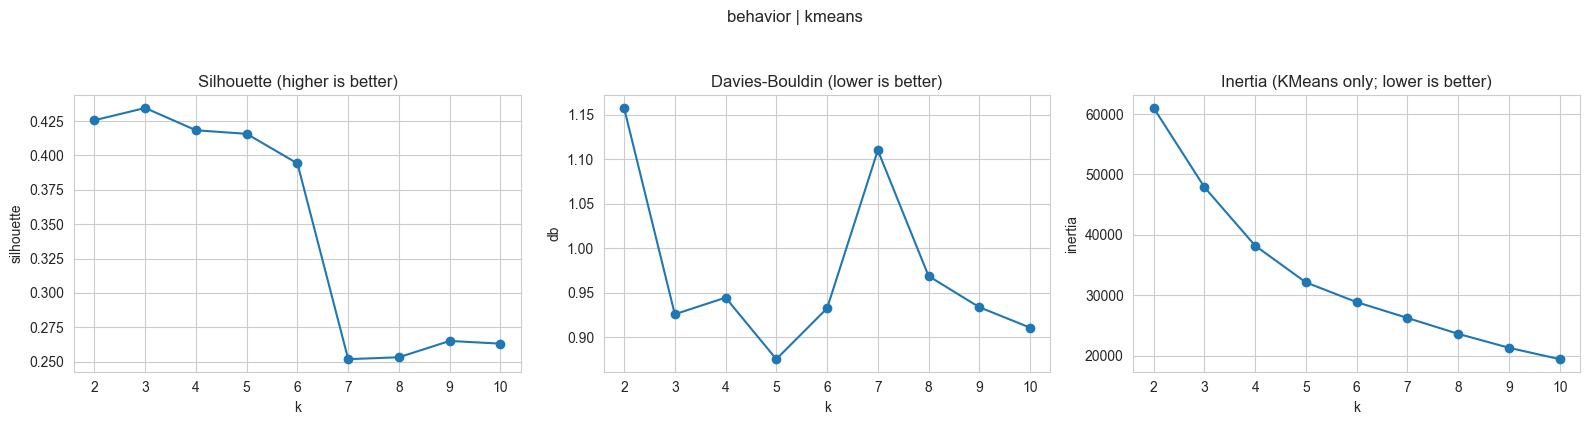

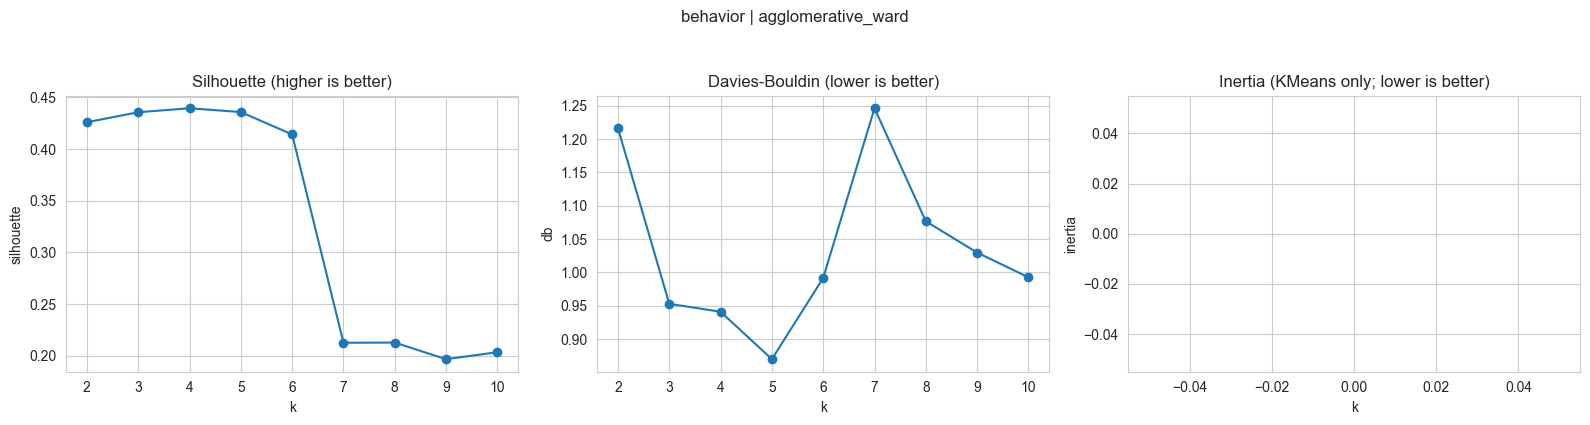

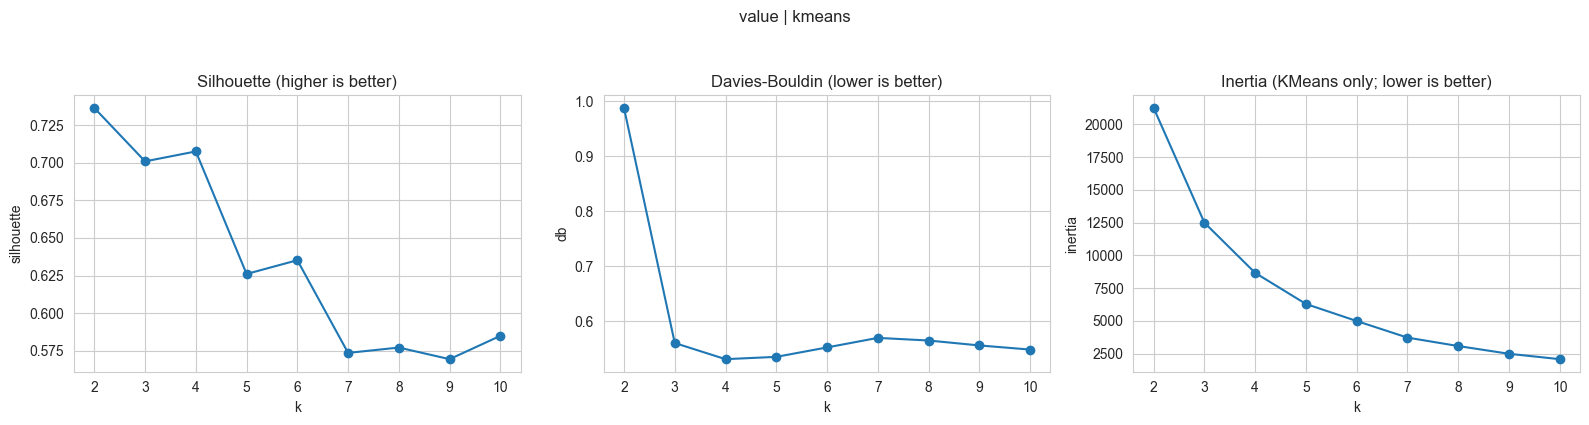

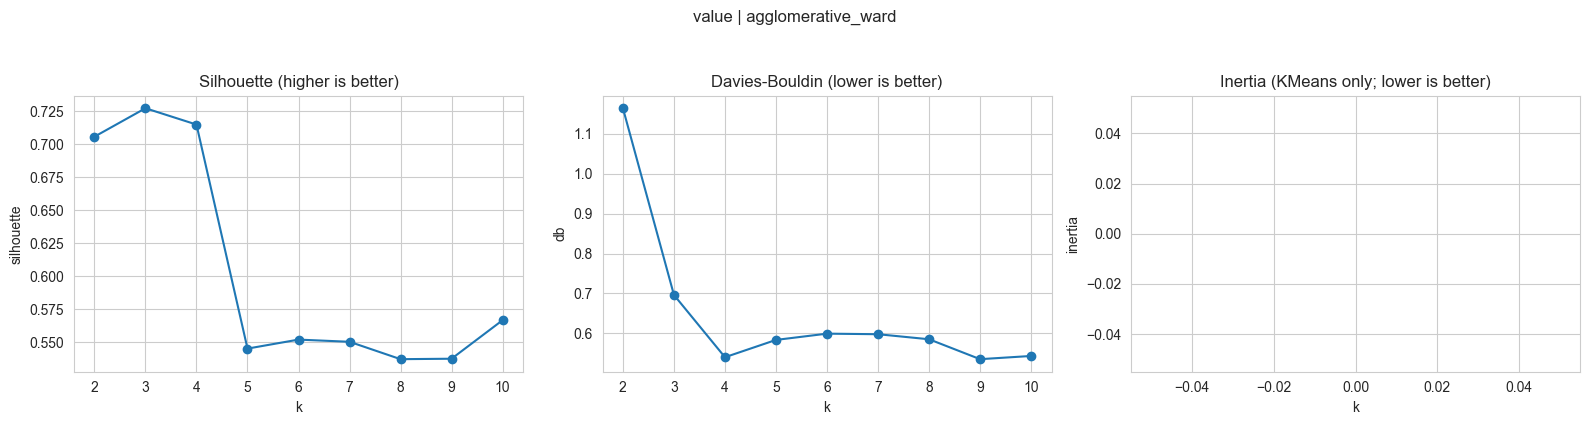

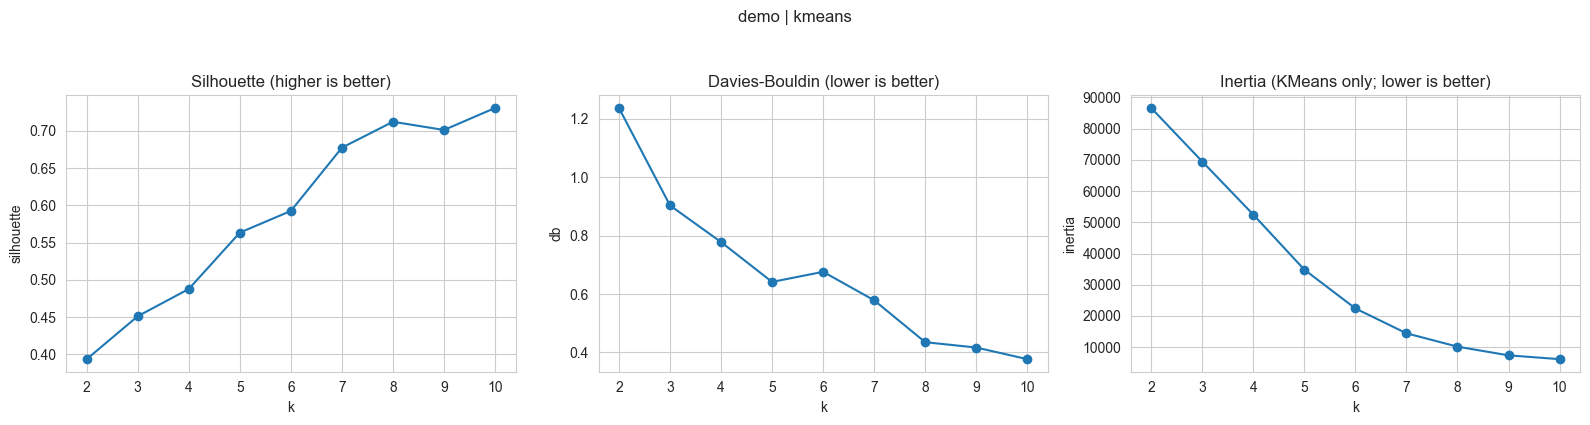

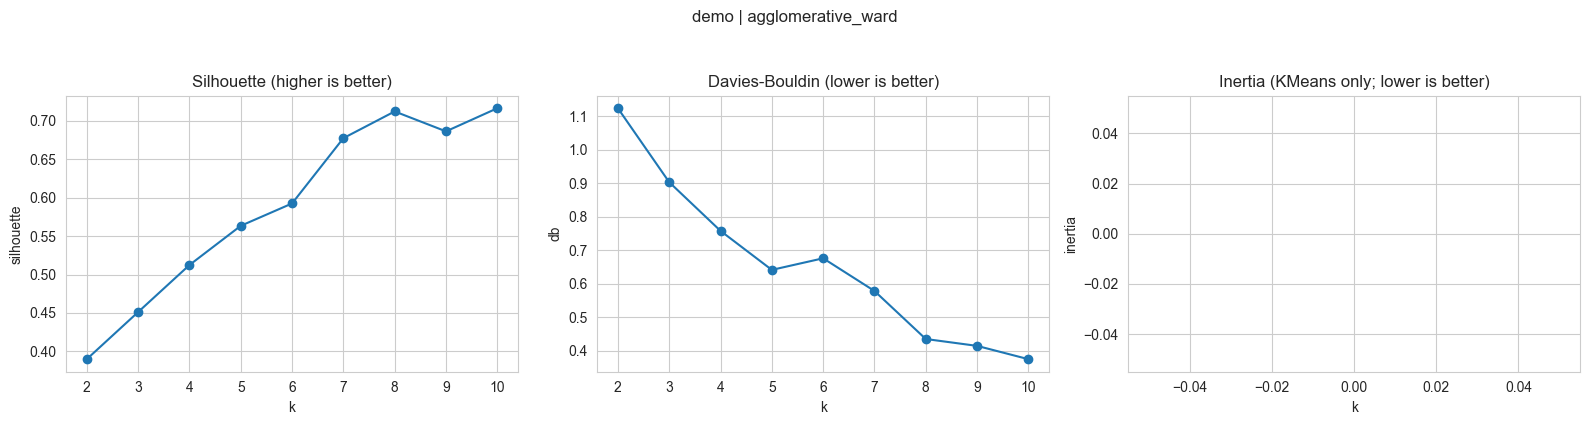

In [18]:
def plot_k_search(sub: pd.DataFrame, feature_set: str, algorithm: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(sub["k"], sub["silhouette"], marker="o")
    axes[0].set_title("Silhouette (higher is better)")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("silhouette")

    axes[1].plot(sub["k"], sub["davies_bouldin"], marker="o")
    axes[1].set_title("Davies-Bouldin (lower is better)")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("db")

    axes[2].plot(sub["k"], sub["inertia"], marker="o")
    axes[2].set_title("Inertia (KMeans only; lower is better)")
    axes[2].set_xlabel("k")
    axes[2].set_ylabel("inertia")

    axes[2].set_xlabel("k")

    fig.suptitle(f"{feature_set} | {algorithm}", y=1.05)
    fig.tight_layout()
    fig.savefig(
        os.path.join(output_dir, f"k_search_{feature_set}_{algorithm}.png"),
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

# Combine all per-cell results into one table
results_df = pd.concat(all_results, ignore_index=True)

print("Best k by silhouette:")
display(pd.DataFrame(best_k))

# Save / show metric plots per (feature_set, algorithm)
for (fs, algo), sub in results_df.groupby(["feature_set", "algorithm"], sort=False):
    plot_k_search(sub, feature_set=str(fs), algorithm=str(algo))

Best k by silhouette:


,kmeans,agglomerative_ward
behavior,3,4
value,2,3
demo,10,10


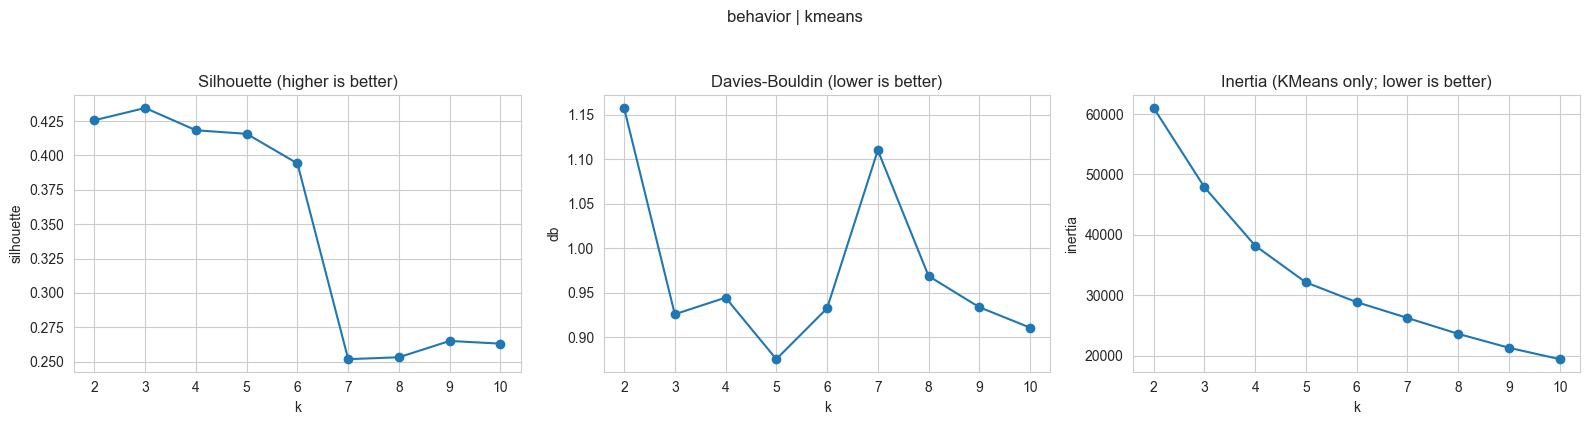

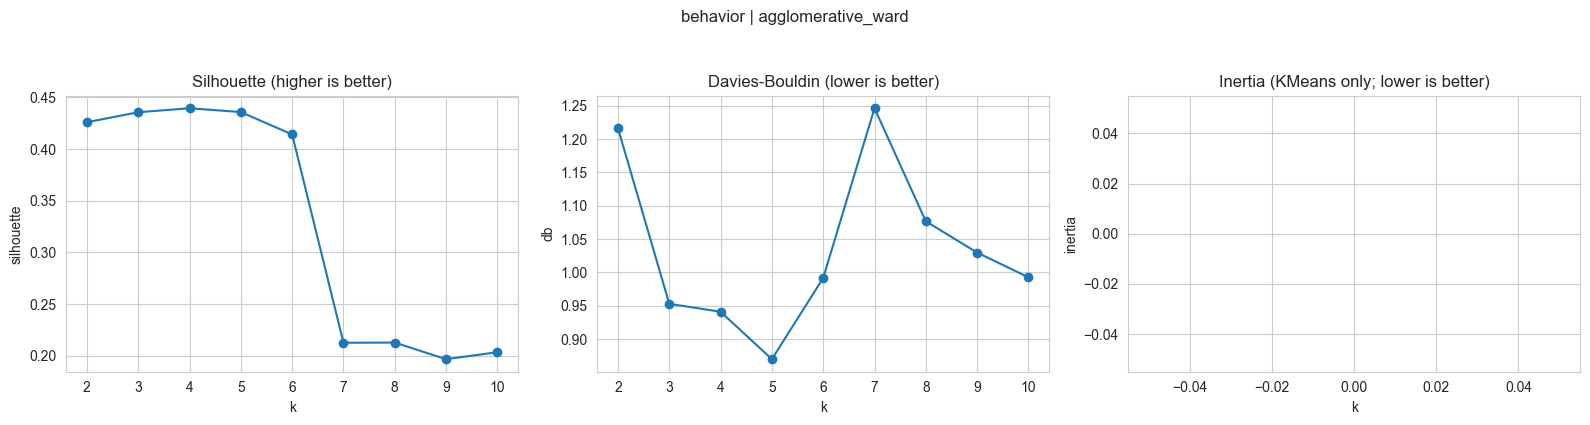

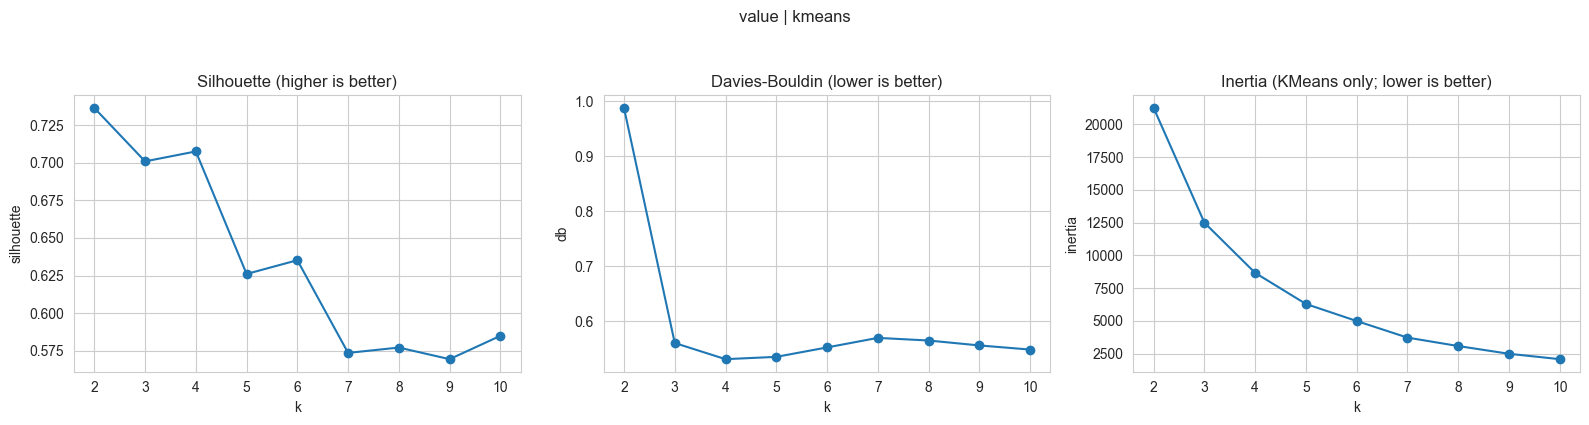

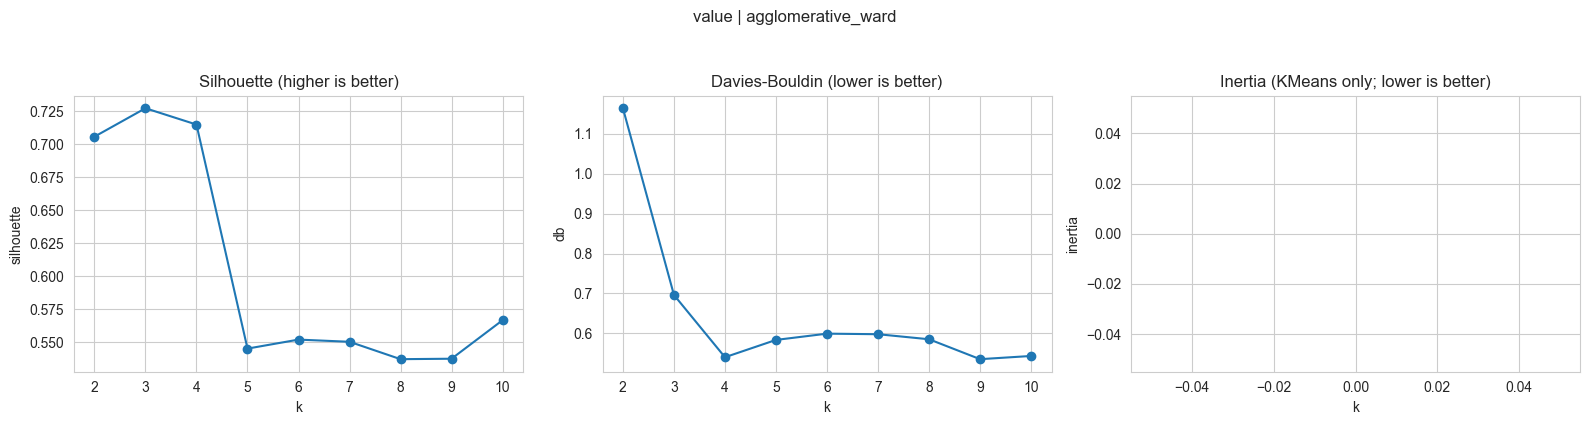

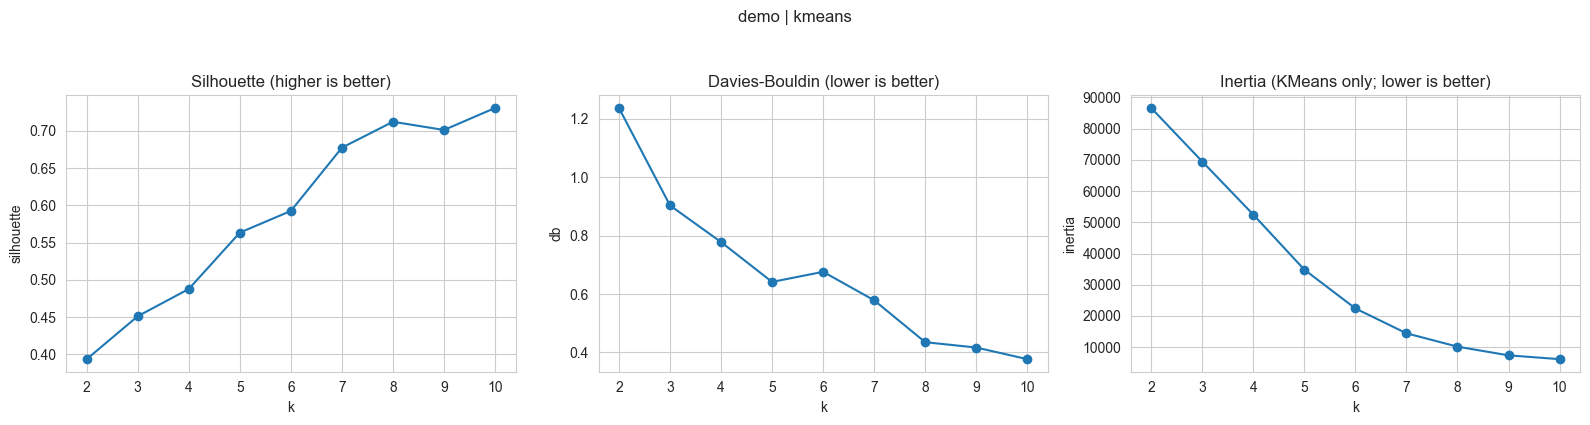

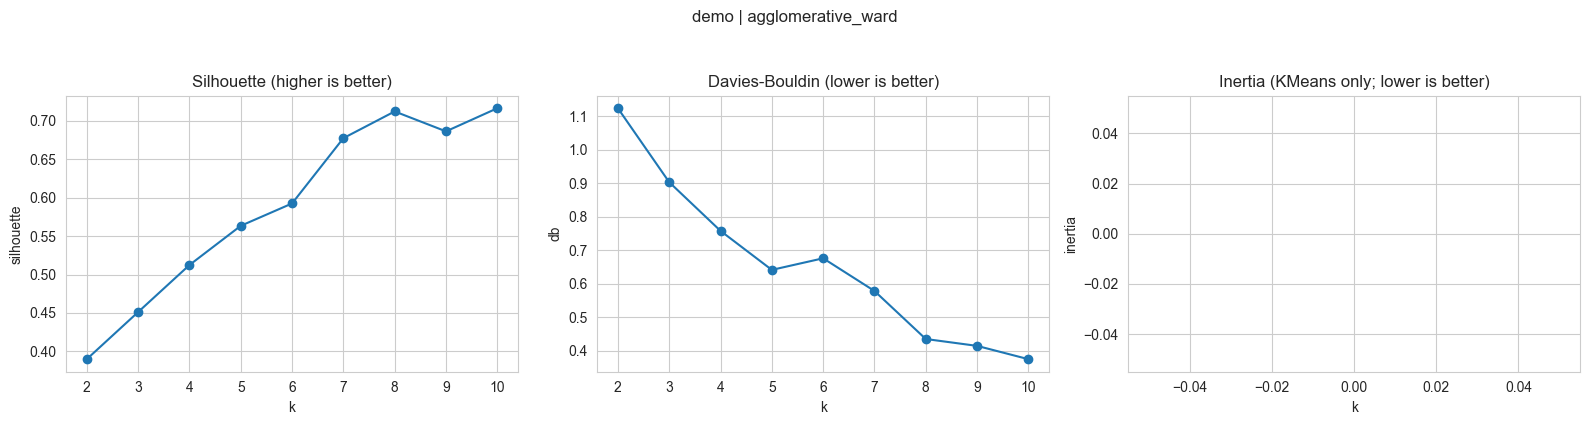

In [19]:
# Combine all per-cell results into one table
results_df = pd.concat(all_results, ignore_index=True)

print("Best k by silhouette:")
display(pd.DataFrame(best_k))

# Save / show metric plots per (feature_set, algorithm)
for (fs, algo), sub in results_df.groupby(["feature_set", "algorithm"], sort=False):
    plot_k_search(sub, feature_set=str(fs), algorithm=str(algo))

In [20]:
final_labels = {}
final_models = {}
final_scores = []


def plot_cluster_separation_pca(X: np.ndarray,labels: np.ndarray,title: str,save_path: str | None = None,show_plot: bool = True,) -> None: 
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plot_df = pd.DataFrame({
        "pc1": X_2d[:, 0],
        "pc2": X_2d[:, 1],
        "cluster": labels.astype(int),
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_df,
        x="pc1",
        y="pc2",
        hue="cluster",
        palette="tab10",
        s=18,
        linewidth=0,
        alpha=0.85,
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    if show_plot:
        plt.show()
    else:
        plt.close()

## Final clustering (per subset)

Runs **KMeans** and **Agglomerative (Ward)** using the previously selected `best_k` for each subset, and plots a 2D PCA visualization of the resulting clusters.

### Behaviour subset

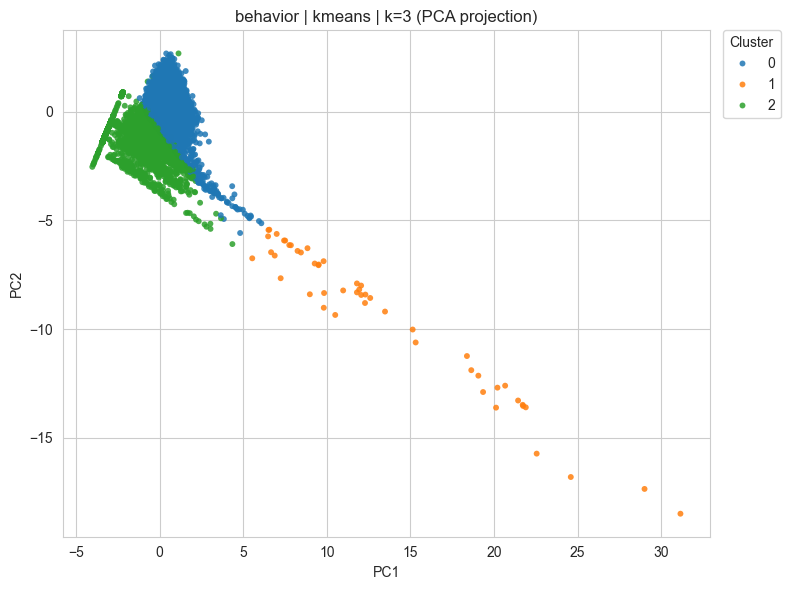

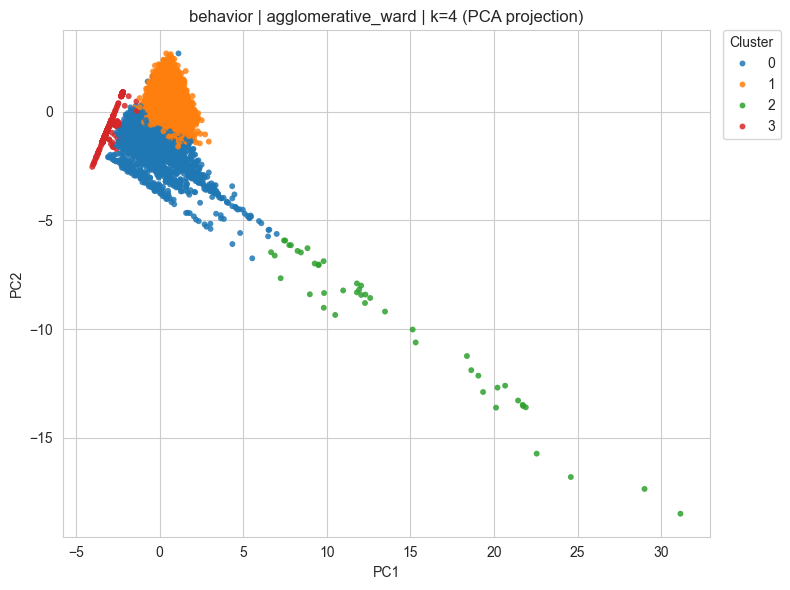

Done: behavior (kmeans k=3, agglomerative_ward k=4)


In [21]:
fs_name = "behavior"
X = feature_sets[fs_name]

# Allow re-running just this subset cleanly
final_scores = [r for r in final_scores if r.get("feature_set") != fs_name]
for key in [(fs_name, "kmeans"), (fs_name, "agglomerative_ward")]:
    final_models.pop(key, None)
    final_labels.pop(key, None)

# --- KMeans ---
k_km = int(best_k["kmeans"][fs_name])
km = KMeans(n_clusters=k_km, random_state=42, n_init=20)
labels_km = km.fit_predict(X)
final_models[(fs_name, "kmeans")] = km
final_labels[(fs_name, "kmeans")] = labels_km
sil, db = _clustering_metrics(X, labels_km)
final_scores.append({
    "feature_set": fs_name,
    "algorithm": "kmeans",
    "k": k_km,
    "silhouette": sil,
    "davies_bouldin": db,
})
plot_cluster_separation_pca(
    X,
    labels_km,
    title=f"{fs_name} | kmeans | k={k_km} (PCA projection)",
    save_path=os.path.join(output_dir, f"separation_pca_{fs_name}_kmeans_k{k_km}.png"),
)

# --- Agglomerative (Ward) ---
k_ag = int(best_k["agglomerative_ward"][fs_name])
ag = AgglomerativeClustering(n_clusters=k_ag, linkage="ward")
labels_ag = ag.fit_predict(X)
final_models[(fs_name, "agglomerative_ward")] = ag
final_labels[(fs_name, "agglomerative_ward")] = labels_ag
sil, db = _clustering_metrics(X, labels_ag)
final_scores.append({
    "feature_set": fs_name,
    "algorithm": "agglomerative_ward",
    "k": k_ag,
    "silhouette": sil,
    "davies_bouldin": db,
})
plot_cluster_separation_pca(
    X,
    labels_ag,
    title=f"{fs_name} | agglomerative_ward | k={k_ag} (PCA projection)",
    save_path=os.path.join(output_dir, f"separation_pca_{fs_name}_agglomerative_ward_k{k_ag}.png"),
)

print(f"Done: {fs_name} (kmeans k={k_km}, agglomerative_ward k={k_ag})")

### Value subset

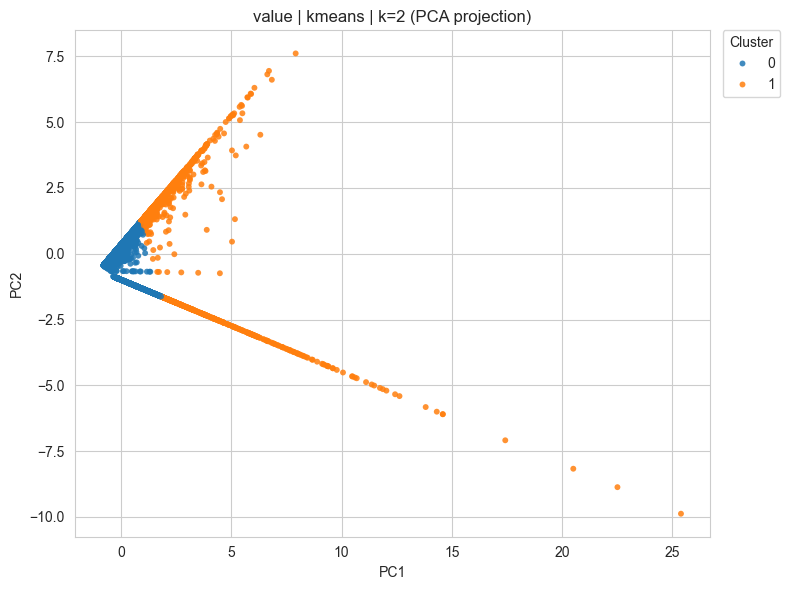

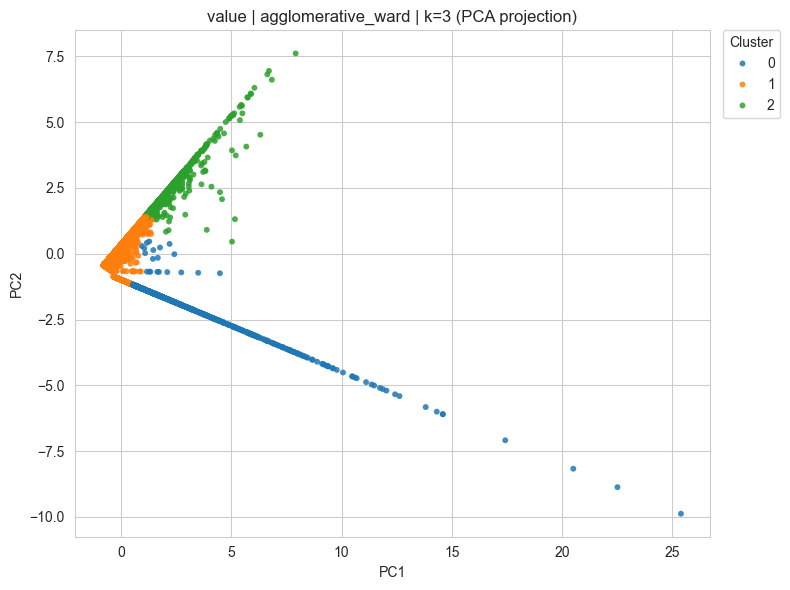

Done: value (kmeans k=2, agglomerative_ward k=3)


In [22]:
fs_name = "value"
X = feature_sets[fs_name]

# Allow re-running just this subset cleanly
final_scores = [r for r in final_scores if r.get("feature_set") != fs_name]
for key in [(fs_name, "kmeans"), (fs_name, "agglomerative_ward")]:
    final_models.pop(key, None)
    final_labels.pop(key, None)

# --- KMeans ---
k_km = int(best_k["kmeans"][fs_name])
km = KMeans(n_clusters=k_km, random_state=42, n_init=20)
labels_km = km.fit_predict(X)
final_models[(fs_name, "kmeans")] = km
final_labels[(fs_name, "kmeans")] = labels_km
sil, db = _clustering_metrics(X, labels_km)
final_scores.append({
    "feature_set": fs_name,
    "algorithm": "kmeans",
    "k": k_km,
    "silhouette": sil,
    "davies_bouldin": db,
})
plot_cluster_separation_pca(
    X,
    labels_km,
    title=f"{fs_name} | kmeans | k={k_km} (PCA projection)",
    save_path=os.path.join(output_dir, f"separation_pca_{fs_name}_kmeans_k{k_km}.png"),
)

# --- Agglomerative (Ward) ---
k_ag = int(best_k["agglomerative_ward"][fs_name])
ag = AgglomerativeClustering(n_clusters=k_ag, linkage="ward")
labels_ag = ag.fit_predict(X)
final_models[(fs_name, "agglomerative_ward")] = ag
final_labels[(fs_name, "agglomerative_ward")] = labels_ag
sil, db = _clustering_metrics(X, labels_ag)
final_scores.append({
    "feature_set": fs_name,
    "algorithm": "agglomerative_ward",
    "k": k_ag,
    "silhouette": sil,
    "davies_bouldin": db,
})
plot_cluster_separation_pca(
    X,
    labels_ag,
    title=f"{fs_name} | agglomerative_ward | k={k_ag} (PCA projection)",
    save_path=os.path.join(output_dir, f"separation_pca_{fs_name}_agglomerative_ward_k{k_ag}.png"),
)

print(f"Done: {fs_name} (kmeans k={k_km}, agglomerative_ward k={k_ag})")

### Demographics subset

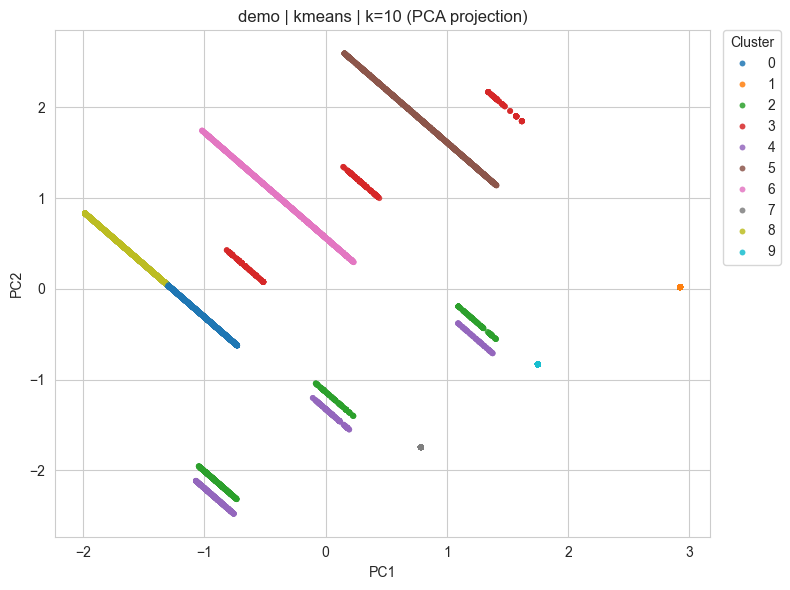

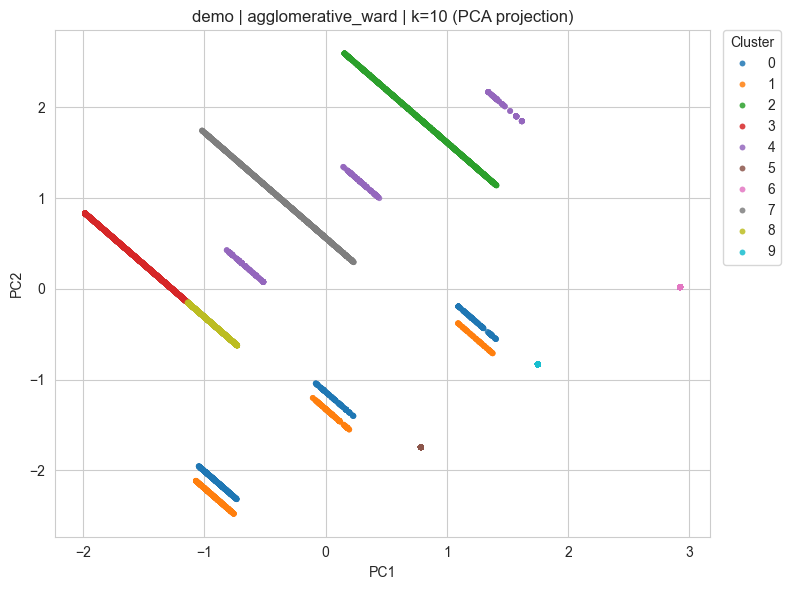

Done: demo (kmeans k=10, agglomerative_ward k=10)


In [23]:
fs_name = "demo"
X = feature_sets[fs_name]

# Allow re-running just this subset cleanly
final_scores = [r for r in final_scores if r.get("feature_set") != fs_name]
for key in [(fs_name, "kmeans"), (fs_name, "agglomerative_ward")]:
    final_models.pop(key, None)
    final_labels.pop(key, None)

# --- KMeans ---
k_km = int(best_k["kmeans"][fs_name])
km = KMeans(n_clusters=k_km, random_state=42, n_init=20)
labels_km = km.fit_predict(X)
final_models[(fs_name, "kmeans")] = km
final_labels[(fs_name, "kmeans")] = labels_km
sil, db = _clustering_metrics(X, labels_km)
final_scores.append({
    "feature_set": fs_name,
    "algorithm": "kmeans",
    "k": k_km,
    "silhouette": sil,
    "davies_bouldin": db,
})
plot_cluster_separation_pca(
    X,
    labels_km,
    title=f"{fs_name} | kmeans | k={k_km} (PCA projection)",
    save_path=os.path.join(output_dir, f"separation_pca_{fs_name}_kmeans_k{k_km}.png"),
)

# --- Agglomerative (Ward) ---
k_ag = int(best_k["agglomerative_ward"][fs_name])
ag = AgglomerativeClustering(n_clusters=k_ag, linkage="ward")
labels_ag = ag.fit_predict(X)
final_models[(fs_name, "agglomerative_ward")] = ag
final_labels[(fs_name, "agglomerative_ward")] = labels_ag
sil, db = _clustering_metrics(X, labels_ag)
final_scores.append({
    "feature_set": fs_name,
    "algorithm": "agglomerative_ward",
    "k": k_ag,
    "silhouette": sil,
    "davies_bouldin": db,
})
plot_cluster_separation_pca(
    X,
    labels_ag,
    title=f"{fs_name} | agglomerative_ward | k={k_ag} (PCA projection)",
    save_path=os.path.join(output_dir, f"separation_pca_{fs_name}_agglomerative_ward_k{k_ag}.png"),
)

print(f"Done: {fs_name} (kmeans k={k_km}, agglomerative_ward k={k_ag})")

### Summary table

In [24]:
scores_df = (pd.DataFrame(final_scores).sort_values(["feature_set", "algorithm"]).reset_index(drop=True))

print("Final model quality (using chosen k):")
display(scores_df)

Final model quality (using chosen k):


,feature_set,algorithm,k,silhouette,davies_bouldin
0,behavior,agglomerative_ward,4,0.439579,0.940952
1,behavior,kmeans,3,0.434529,0.925727
2,demo,agglomerative_ward,10,0.716583,0.374700
3,demo,kmeans,10,0.730937,0.376897
4,value,agglomerative_ward,3,0.727196,0.696220
5,value,kmeans,2,0.736542,0.988216


### Radar charts (cluster profiles)
These radar charts summarize how each cluster differs across selected features (values are min–max normalized across clusters for readability).
- **Behavior / Value**: normalized means of the original numeric features.
- **Demographics**: `Income` (numeric) plus a small set of one-hot demographic indicators (Education / Marital Status). For one-hot indicators, the values represent the *proportion of customers in the cluster* with that category.

In [25]:
def radar_cluster_profiles(feature_df: pd.DataFrame,labels: np.ndarray,title: str,save_path: str | None = None,) -> None:
    plot_df = feature_df.copy()
    plot_df["cluster"] = labels
    centers = plot_df.groupby("cluster").mean(numeric_only=True)
    if centers.shape[0] < 2:
        print(f"Skipping radar (need >=2 clusters): {title}")
        return

    # Normalize features across clusters for readability (0..1 per feature)
    denom = (centers.max() - centers.min()).replace(0, np.nan)
    centers_norm = ((centers - centers.min()) / denom).fillna(0.0)

    features = centers_norm.columns.tolist()
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False)
    angles = np.concatenate([angles, angles[:1]])

    fig = plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    ax.set_title(title, y=1.08)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)
    ax.set_ylim(0, 1)

    for cluster_id, row in centers_norm.iterrows():
        values = row.values
        values = np.concatenate([values, values[:1]])
        ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster_id}")
        ax.fill(angles, values, alpha=0.08)

    ax.legend(bbox_to_anchor=(1.25, 1.05), loc="upper left")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

def _select_top_demo_indicators(demo_encoded_df: pd.DataFrame,labels: np.ndarray,prefixes: tuple[str, ...] = ("Education_", "Marital Status_"),top_n: int = 8,) -> list[str]:
    """Pick the most informative one-hot demographic indicators by variance across cluster means."""
    candidate_cols = [
        c for c in demo_encoded_df.columns
        if any(c.startswith(p) for p in prefixes)
    ]
    if not candidate_cols:
        return []

    tmp = demo_encoded_df[candidate_cols].copy()
    tmp["cluster"] = labels
    centers = tmp.groupby("cluster").mean(numeric_only=True)
    if centers.shape[0] < 2:
        return []

    # Higher variance across cluster means => more discriminative for clusters
    variances = centers.var(axis=0).sort_values(ascending=False)
    return variances.head(int(top_n)).index.tolist()

def _pretty_demo_name(col: str) -> str:
    if col.startswith("Education_"):
        return "Edu: " + col.replace("Education_", "")
    if col.startswith("Marital Status_"):
        return "Marital: " + col.replace("Marital Status_", "")
    return col

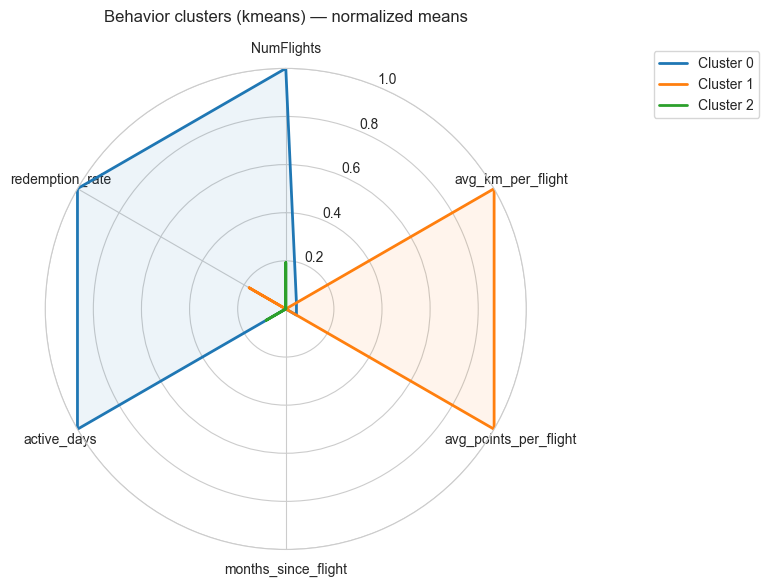

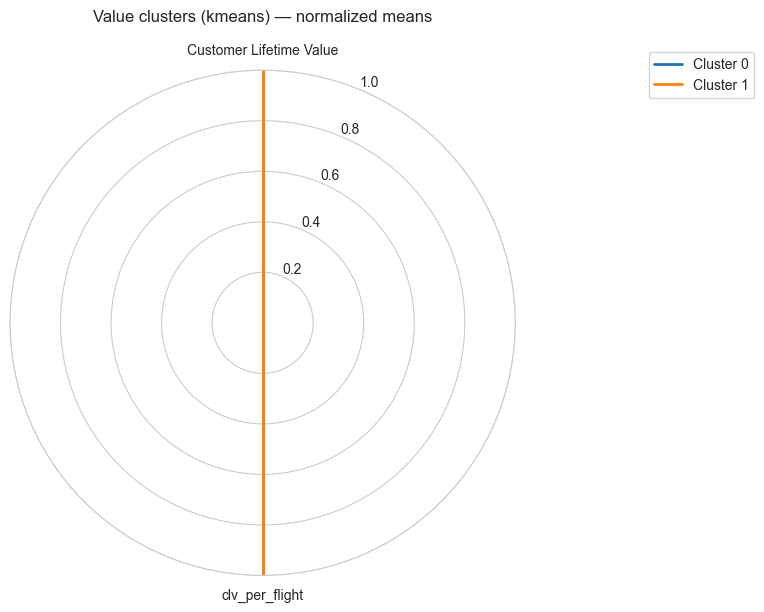

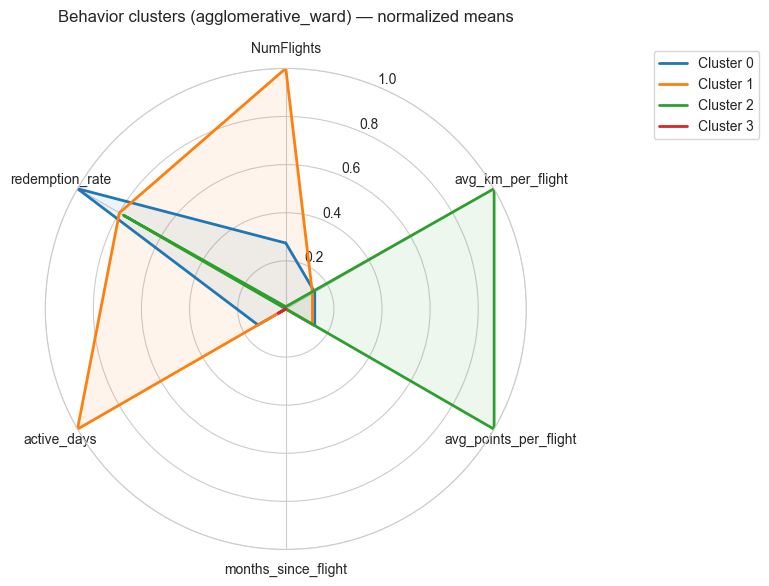

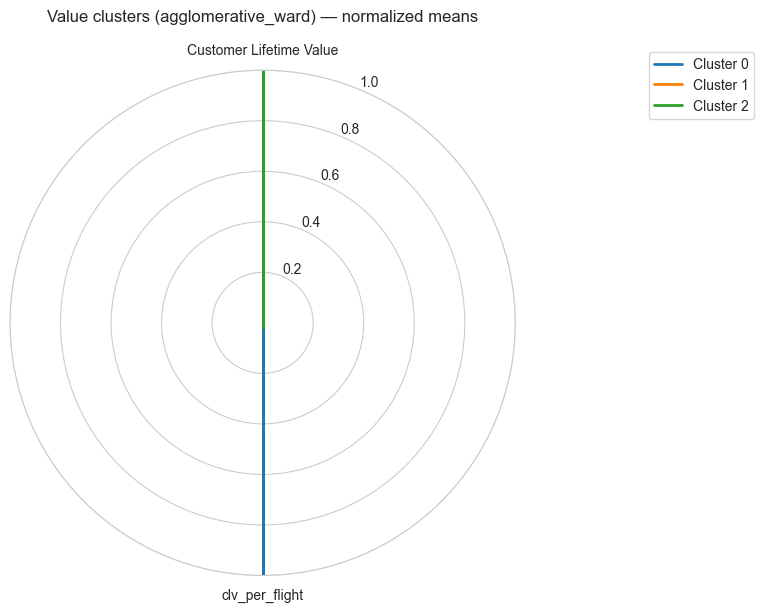

In [26]:
# Produce radar charts for BOTH algorithms
algorithms_for_radar = ("kmeans", "agglomerative_ward")

for algo_for_radar in algorithms_for_radar:
    # Behavior radar
    key = ("behavior", algo_for_radar)
    if key in final_labels:
        radar_cluster_profiles(
            X_behavior_df[behavior_features],
            final_labels[key],
            title=f"Behavior clusters ({algo_for_radar}) — normalized means",
            save_path=os.path.join(output_dir, f"radar_behavior_{algo_for_radar}.png"),
        )
    else:
        print(f"No labels found for {key}; run the final clustering cells first.")

    # Value radar
    key = ("value", algo_for_radar)
    if key in final_labels:
        radar_cluster_profiles(
            X_value_df[value_features],
            final_labels[key],
            title=f"Value clusters ({algo_for_radar}) — normalized means",
            save_path=os.path.join(output_dir, f"radar_value_{algo_for_radar}.png"),
        )
    else:
        print(f"No labels found for {key}; run the final clustering cells first.")

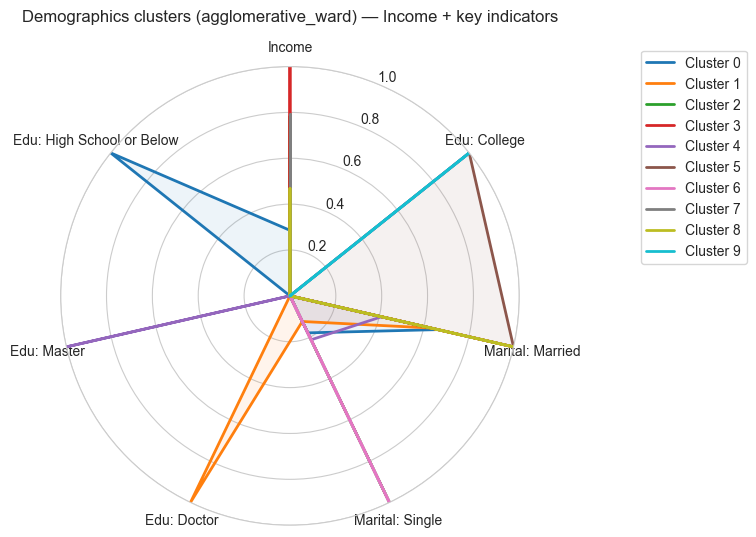

In [ ]:
# Demographics radar (Income + selected one-hot indicators)

# If you run this cell on its own, ensure the algorithm list exists.
algorithms_for_radar = ("kmeans", "agglomerative_ward")
for algo_for_radar in algorithms_for_radar:
    key = ("demo", algo_for_radar)
    if key in final_labels:
        demo_labels = final_labels[key]
        top_demo_cols = _select_top_demo_indicators(X_demo_encoded, demo_labels, top_n=8)
        demo_radar_df = pd.concat(
            [
                X_demo_df[["Income"]],
                X_demo_encoded[top_demo_cols] if top_demo_cols else pd.DataFrame(index=X_demo_df.index),
            ],
            axis=1,
        )
        demo_radar_df = demo_radar_df.rename(columns={c: _pretty_demo_name(c) for c in demo_radar_df.columns})
        radar_cluster_profiles(
            demo_radar_df,
            demo_labels,
            title=f"Demographics clusters ({algo_for_radar}) — Income + key indicators",
            save_path=os.path.join(output_dir, f"radar_demo_{algo_for_radar}.png"),
        )
    else:
        print(f"No labels found for {key}; run the final clustering cells first.")

In [28]:
df = df.copy()

df["cluster_behavior_kmeans"] = final_labels[("behavior", "kmeans")]
df["cluster_value_kmeans"] = final_labels[("value", "kmeans")]
df["cluster_demo_kmeans"] = final_labels[("demo", "kmeans")]

df["cluster_behavior_agglomerative_ward"] = final_labels[("behavior", "agglomerative_ward")]
df["cluster_value_agglomerative_ward"] = final_labels[("value", "agglomerative_ward")]
df["cluster_demo_agglomerative_ward"] = final_labels[("demo", "agglomerative_ward")]

print("Cluster sizes (KMeans):")
display(df[["cluster_behavior_kmeans", "cluster_value_kmeans", "cluster_demo_kmeans"]].apply(pd.Series.value_counts).fillna(0).astype(int))

print("Cluster sizes (Agglomerative Ward):")
display(df[["cluster_behavior_agglomerative_ward", "cluster_value_agglomerative_ward", "cluster_demo_agglomerative_ward"]].apply(pd.Series.value_counts).fillna(0).astype(int))

df.head()

Cluster sizes (KMeans):


,cluster_behavior_kmeans,cluster_value_kmeans,cluster_demo_kmeans
0,11731,15211,3645
1,50,1526,2426
2,4956,0,782
3,0,0,508
4,0,0,734
5,0,0,1719
6,0,0,1644
7,0,0,1436
8,0,0,3467
9,0,0,376


Cluster sizes (Agglomerative Ward):


,cluster_behavior_agglomerative_ward,cluster_value_agglomerative_ward,cluster_demo_agglomerative_ward
0,3521,1046,782
1,11624,14811,734
2,45,880,1719
3,1547,0,4398
4,0,0,508
5,0,0,1436
6,0,0,2426
7,0,0,1644
8,0,0,2714
9,0,0,376


,Loyalty#,Country,Province or State,City,Gender,Education,Income,Marital Status,LoyaltyStatus,NumFlights,DistanceKM,PointsAccumulated,PointsRedeemed,Customer Lifetime Value,months_since_flight,active_days,avg_km_per_flight,avg_points_per_flight,clv_per_flight,redemption_rate,cluster_behavior_kmeans,cluster_value_kmeans,cluster_demo_kmeans,cluster_behavior_agglomerative_ward,cluster_value_agglomerative_ward,cluster_demo_agglomerative_ward
0,100018,Canada,Alberta,Edmonton,female,Bachelor,82877.0,Married,Aurora,231,530230.0,53014.30,20562.8,7919.20,0,2326,2295.367965,229.499134,34.282251,38.787271,0,0,8,1,1,3
1,100102,Canada,Ontario,Toronto,male,College,0.0,Single,Nova,248,339114.6,33903.96,18760.6,2887.74,0,3574,1367.397581,136.709516,11.644113,55.334539,0,0,1,1,1,6
2,100140,Canada,British Columbia,Dawson Creek,female,College,0.0,Divorced,Nova,217,432030.8,43192.58,4896.0,2838.07,0,2336,1990.925346,199.044147,13.078664,11.335280,0,0,9,1,1,9
3,100214,Canada,British Columbia,Vancouver,male,Bachelor,42837.0,Married,Star,112,364601.7,36453.77,12908.6,4170.57,0,2694,3255.372321,325.480089,37.237232,35.410878,0,0,0,1,1,8
4,100272,Canada,Ontario,Toronto,female,Bachelor,80979.0,Divorced,Star,187,429630.5,42953.25,10891.4,6622.05,0,3268,2297.489305,229.696524,35.412032,25.356405,0,0,6,1,1,7


## Final segmentation logic (Behaviour × Value)

Goal: produce a **single, business-friendly segmentation** by combining the two most actionable perspectives:
- **Behaviour cluster** (how customers fly/engage)
- **Value cluster** (how valuable they are)

This section creates:
1) A merged customer-level segmentation table
2) Cross-tabs between behaviour and value assignments
3) A mapping from *(behaviour level × value level)* → **final segment name**

In [29]:
def _zscore(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    denom = s.std(ddof=0)
    if denom == 0 or pd.isna(denom):
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / denom

def _level_from_scores(cluster_scores: pd.Series) -> pd.Series:
    """Return Low/Medium/High levels for clusters based on their score ordering."""
    cluster_scores = cluster_scores.sort_values()
    n = int(cluster_scores.shape[0])
    if n >= 3:
        # tertiles; if ties cause qcut issues, fall back to rank-based bins
        try:
            return pd.qcut(cluster_scores, q=3, labels=["Low", "Medium", "High"])
        except Exception:
            pass
    # rank-based fallback for small n or heavy ties
    ranks = cluster_scores.rank(method="dense")
    max_rank = int(ranks.max()) if len(ranks) else 1

    def _to_level(r: float) -> str:
        if max_rank <= 1:
            return "Medium"
        if r <= max_rank / 3:
            return "Low"
        if r <= 2 * max_rank / 3:
            return "Medium"
        return "High"

    return ranks.map(_to_level)

def build_final_segmentation(df_customer: pd.DataFrame,behavior_cluster_col: str,value_cluster_col: str,prefix: str,out_dir: str = "Data",) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Build a Behaviour×Value final segmentation for one algorithm (kmeans or agglomerative).
    Returns: (segmentation_table, mapping_table, crosstab_table)
    """
    required_cols = {
        "Loyalty#",
        behavior_cluster_col,
        value_cluster_col,
        "NumFlights",
        "months_since_flight",
        "active_days",
        "redemption_rate",
        "Customer Lifetime Value",
        "clv_per_flight",
    }
    missing = [c for c in required_cols if c not in df_customer.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df_out = df_customer.copy()
    
    # Behaviour: frequent + active + recently flown + engaged (redemption)
    behavior_score = (_zscore(df_out["NumFlights"])+ _zscore(df_out["active_days"])- _zscore(df_out["months_since_flight"])+ 0.5 * _zscore(df_out["redemption_rate"]))

    # Value: CLV signal
    value_score = _zscore(df_out["Customer Lifetime Value"]) + _zscore(df_out["clv_per_flight"])
    df_out[f"{prefix}_behavior_score"] = behavior_score
    df_out[f"{prefix}_value_score"] = value_score

    # Cluster-level mean scores
    b_cluster_scores = df_out.groupby(behavior_cluster_col)[f"{prefix}_behavior_score"].mean().astype(float)
    v_cluster_scores = df_out.groupby(value_cluster_col)[f"{prefix}_value_score"].mean().astype(float)

    b_level = _level_from_scores(b_cluster_scores)
    v_level = _level_from_scores(v_cluster_scores)

    df_out[f"{prefix}_behavior_level"] = df_out[behavior_cluster_col].map(b_level.to_dict())
    df_out[f"{prefix}_value_level"] = df_out[value_cluster_col].map(v_level.to_dict())

    # Business-friendly segment names (3×3 grid) ---
    segment_name_map: dict[tuple[str, str], str] = {
        ("High", "High"): "Elite Frequent Flyers",
        ("High", "Medium"): "Loyal Premium Travelers",
        ("High", "Low"): "High-Value At-Risk",
        ("Medium", "High"): "Rising Loyalists",
        ("Medium", "Medium"): "Mainstream Core Travelers",
        ("Medium", "Low"): "Value Fading",
        ("Low", "High"): "Engaged Bargain Seekers",
        ("Low", "Medium"): "Occasional Leisure Travelers",
        ("Low", "Low"): "Dormant / Churned",
    }

    df_out[f"{prefix}_final_segment"] = df_out.apply(
        lambda r: segment_name_map.get(
            (str(r[f"{prefix}_value_level"]), str(r[f"{prefix}_behavior_level"])),"Unassigned",),axis=1,)

    # Mapping table: (behaviour cluster, value cluster) → final segment (with size)
    mapping = (
        df_out.groupby([behavior_cluster_col, value_cluster_col])[f"{prefix}_final_segment"]
        .agg([("final_segment", "first"), ("customers", "size")])
        .reset_index()
        .sort_values(["customers"], ascending=False)
        .reset_index(drop=True)
    )

    # Cross-tab table (counts)
    ctab = pd.crosstab(df_out[behavior_cluster_col], df_out[value_cluster_col])

    # A compact “merged segmentation table” (customer-level)
    merged = df_out[[
        "Loyalty#",
        behavior_cluster_col,
        value_cluster_col,
        f"{prefix}_behavior_level",
        f"{prefix}_value_level",
        f"{prefix}_final_segment",
    ]].copy()

    # Save outputs
    os.makedirs(out_dir, exist_ok=True)
    merged.to_csv(os.path.join(out_dir, f"final_segmentation_{prefix}_customers.csv"), index=False)
    mapping.to_csv(os.path.join(out_dir, f"final_segmentation_{prefix}_mapping.csv"), index=False)
    ctab.to_csv(os.path.join(out_dir, f"final_segmentation_{prefix}_crosstab.csv"))

    return merged, mapping, ctab

In [30]:
seg_km, map_km, ctab_km = build_final_segmentation(
    df,
    behavior_cluster_col="cluster_behavior_kmeans",
    value_cluster_col="cluster_value_kmeans",
    prefix="kmeans",
    out_dir="Data",
)
seg_ag, map_ag, ctab_ag = build_final_segmentation(
    df,
    behavior_cluster_col="cluster_behavior_agglomerative_ward",
    value_cluster_col="cluster_value_agglomerative_ward",
    prefix="agglomerative_ward",
    out_dir="Data",
)

print("KMeans: Behaviour×Value cross-tab")
display(ctab_km)
print("KMeans: Mapping (behaviour cluster × value cluster → final segment)")
display(map_km.head(20))

print("Agglomerative (Ward): Behaviour×Value cross-tab")
display(ctab_ag)
print("Agglomerative (Ward): Mapping (behaviour cluster × value cluster → final segment)")
display(map_ag.head(20))

# Merge back final segments into df for convenience
df = df.merge(seg_km, on=["Loyalty#", "cluster_behavior_kmeans", "cluster_value_kmeans"], how="left")
df = df.merge(seg_ag, on=["Loyalty#", "cluster_behavior_agglomerative_ward", "cluster_value_agglomerative_ward"], how="left")

# Save a single merged table (customer-level) with both algorithms' final segments
cols_to_save = [c for c in df.columns if c.startswith("kmeans_") or c.startswith("agglomerative_ward_") or c in ["Loyalty#"]]
df[cols_to_save].to_csv(os.path.join("Data", "DM_AIAI_FinalCustomerSegments_withFinalSegmentation.csv"), index=False)
print("Saved:", os.path.join("Data", "DM_AIAI_FinalCustomerSegments_withFinalSegmentation.csv"))

KMeans: Behaviour×Value cross-tab


cluster_value_kmeans,0,1
cluster_behavior_kmeans,,
0,10865,866
1,39,11
2,4307,649


KMeans: Mapping (behaviour cluster × value cluster → final segment)


,cluster_behavior_kmeans,cluster_value_kmeans,final_segment,customers
0,0,0,Rising Loyalists,10865
1,2,0,Mainstream Core Travelers,4307
2,0,1,Elite Frequent Flyers,866
3,2,1,Loyal Premium Travelers,649
4,1,0,Value Fading,39
5,1,1,High-Value At-Risk,11


Agglomerative (Ward): Behaviour×Value cross-tab


cluster_value_agglomerative_ward,0,1,2
cluster_behavior_agglomerative_ward,,,
0,16,3320,185
1,0,10932,692
2,18,26,1
3,1012,533,2


Agglomerative (Ward): Mapping (behaviour cluster × value cluster → final segment)


,cluster_behavior_agglomerative_ward,cluster_value_agglomerative_ward,final_segment,customers
0,1,1,Engaged Bargain Seekers,10932
1,0,1,Engaged Bargain Seekers,3320
2,3,0,High-Value At-Risk,1012
3,1,2,Rising Loyalists,692
4,3,1,Dormant / Churned,533
5,0,2,Rising Loyalists,185
6,2,1,Dormant / Churned,26
7,2,0,High-Value At-Risk,18
8,0,0,Elite Frequent Flyers,16
9,3,2,Value Fading,2


Saved: Data\DM_AIAI_FinalCustomerSegments_withFinalSegmentation.csv
